In [1]:
# import packages and functions
import numpy as np
import sys
import matplotlib.pyplot as plt
import xarray as xr
import matplotlib as mpl
import time
import gsw
from matplotlib.colors import TwoSlopeNorm

# import existing python files
plt.rcParams['figure.figsize'] = (10,4)

# add rdmds reading functions to path
sys.path.append("/home/mmurakami/MITgcm/MITgcm_c68r/MITgcm-checkpoint68r/utils/python/MITgcmutils/MITgcmutils/") # go to parent dir
from mds import *

# add the other files
sys.path.append("/home/mmurakami/crios_backups/an_helper_functions")
from read_binary import *
from mk3D_mod import mk3D_mod
from aste_helper_funcs import *
from timing_functions import *           # ts2dte, get_fnames, etc.

# ignore warnings
import warnings
warnings.filterwarnings('ignore')

import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import pandas as pd  # For rolling mean

%run /home/mmurakami/crios_backups/an_helper_functions/prep_grid.py

(50,) (50, 1350, 270)
hf1 (1350, 270)
(1, 1350, 270)
LwetC2d 146614
LwetC 4833023



In [2]:
path = "/home/mmurakami/crios_backups/ASTE_270/Pemberton_BarentsSpaper/ASTE_figs/figs/"

In [3]:
dirIn_new = "/scratch3/atnguyen/aste_270x450x180/run_c68v_adxOFF_20022023_capxxN50_it0062_pk0000000007_bro/diags/BUDG/"

In [4]:
# # load the landmask
hfac = mygrid['hFacC']
landmsk = hfac[0]
landmsk[np.isnan(landmsk)] = 2
landmsk[landmsk == 1] = np.nan

In [5]:
mymsk = np.load('mask_Lind.npz')
mymsk = mymsk['msk1']
mask = mymsk

Text(440, 430, 'Mask: 76.25°N - 78.5°N\n27°E - 41°E')

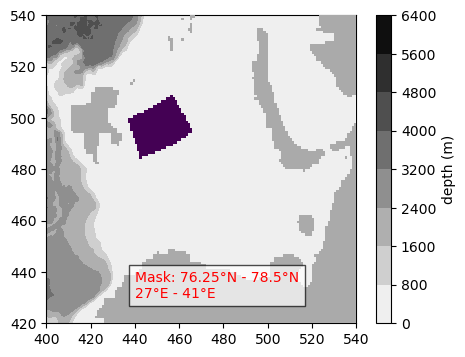

In [6]:
a = np.full(mskBasin.shape,np.nan)
# a[525:555:,35:55] = 1

# create the mask based on lat long
lon = mygrid['XC']
lat = mygrid['YC']
mask = np.zeros_like(lat)
mask[(lat >= 73.25) & (lat <= 80) & (lon >= 20) & (lon <= 55)] = 1  # Masked region
# mask[(lat >= 73.25) & (lat <= 80) & (lon >= 20) & (lon <= 55)] = 1  # Masked region

mask[mask == 0 ] = np.nan


fig = plt.figure(figsize=(5,4))

# cb = plt.pcolormesh(get_aste_tracer(mygrid['Depth'],nfx,nfy)[0],cmap="gray_r",vmin=0,vmax=300)
cb = plt.contourf(get_aste_tracer(mygrid['Depth'],nfx,nfy)[0],cmap="gray_r")
plt.colorbar(cb,label="depth (m)")

plt.pcolormesh(get_aste_tracer(mymsk,nfx,nfy)[0],zorder=2)
plt.pcolormesh(get_aste_tracer(hfac,nfx,nfy)[0],zorder=4,cmap="gray_r",vmin=1,vmax=4)

plt.xlim(400,540)
plt.ylim(420,540)

# plt.text(440, 430, "Mask: 73.25°N - 80°N\n20°E - 55°E", color="red", fontsize=10, 
#          bbox=dict(facecolor='white', alpha=0.7, edgecolor='black'),zorder=10)
plt.text(440, 430, "Mask: 76.25°N - 78.5°N\n27°E - 41°E", color="red", fontsize=10, 
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='black'),zorder=10)

# plt.savefig(path + "mask_Lind.png",dpi=300)

In [8]:
# copy the files we need from the timeseries, make sure we know what we're looking at
# get the timesteps for the year 2007
# ocean and ice
AB_gT=0
AB_gS=0
dt_aste = 600
startyr = 2002
endyr = 2019              # for ASTE R1

# all the filenames in the system
fnames = get_fnames(dt_aste,startyr,endyr)
allyears = np.arange(2003,2018,1)

## Create the budget for this mask

In [10]:
forward_path = "/scratch/atnguyen/aste_270x450x180/OFFICIAL_ASTE_R1_Sep2019/"
layers_path = "/scratch3/atnguyen/aste_270x450x180/run_c68v_layers_lessmem1_adxOFF_Jan2007_capxxN50_it0062_pk0000262944_bro/"
dirdiags = forward_path + "diags/BUDG/"
dirstate = forward_path + "diags/STATE/"
dirLayers = layers_path + "diags/LAYERS/"

In [11]:
# --- Load original edges to get bounds only ---
_T_edges_raw = rdmds(layers_path + "layers2TH").reshape(-1)
_S_edges_raw = rdmds(layers_path + "layers1SLT").reshape(-1)

# --- Define bin count and recompute uniform edges ---
# adding a number of bins here will allow us to perform the limit for small/large nT or nS
nT = 70
nS = 70

nT = 150
nS = 150

#T_edges = np.linspace(_T_edges_raw[0], _T_edges_raw[-1], nT + 1)                             # boundsT
#S_edges = np.linspace(_S_edges_raw[0], _S_edges_raw[-1], nS + 1)                             # boundsS
T_edges = _T_edges_raw
S_edges = _S_edges_raw
boundsT,boundsS = T_edges,S_edges
nT,nS = 112,112

# --- Everything else derived programmatically ---
T_centers      = 0.5 * (T_edges[:-1] + T_edges[1:])                                          # binmidT, binsTH_centers
S_centers      = 0.5 * (S_edges[:-1] + S_edges[1:])                                          # binmidS, binsSLT_centers
binmidT = T_centers
binmidS = S_centers

dT_edges       = T_edges[1:] - T_edges[:-1]                                                  # binwidthT
dS_edges       = S_edges[1:] - S_edges[:-1]                                                  # binwidthS

# these are the points we normalize for the J term --  i
dT_centers     = 0.5 * (dT_edges[:-1] + dT_edges[1:])                                        # binwidthT1
dS_centers     = 0.5 * (dS_edges[:-1] + dS_edges[1:])                                        # binwidthS1
binwidthT1 = dT_centers
binwidthS1 = dS_centers

T_inner_edges  = T_edges[1:-1]                                                               # binmidTp
S_inner_edges  = S_edges[1:-1]                                                               # binmidSp

T_edges_2d,       S_edges_2d       = np.meshgrid(T_edges,       S_edges)
T_centers_2d,     S_centers_2d     = np.meshgrid(T_centers,     S_centers)
T_inner_edges_2d, S_inner_edges_2d = np.meshgrid(T_inner_edges, S_inner_edges)

dT_3d, dS_3d = np.meshgrid(dT_edges, dS_edges)
dT_3d = dT_3d.reshape(nS, nT, 1)
dS_3d = dS_3d.reshape(nS, nT, 1)

# set the mesh for plotting
binmidTp = T_edges[1:-1]
binmidSp = S_edges[1:-1]
Tbin2,Sbin2 = np.meshgrid(binmidTp,binmidSp) # for plotting the J terms individually as vectors!
bincentTp = T_centers[1:-1]
bincentSp = S_centers[1:-1]
Sbin3,Tbin3 = Sbin2[1:-1,1:-1],Tbin2[1:-1,1:-1]    # this is now correct, should be same placement as edges but -1 on both ends

In [ ]:
# copy the files we need from the timeseries, make sure we know what we're looking at
# get the timesteps for the year 2007
# ocean and ice
AB_gT=0
AB_gS=0
dt_aste = 600
startyr = 2002
endyr = 2019              # for ASTE R1

# all the filenames in the system
fnames = get_fnames(dt_aste,startyr,endyr)
allyears = np.arange(2003,2018,1)

In [13]:
# let's move the gate calculation to a function to show a timeseries
# define tstep 
dt_aste = 600
startyr = 2002
endyr = 2019

# all the filenames in the system
fnames = get_fnames(dt_aste,startyr,endyr)

times = {}
times['2007'] = np.arange(3,5,1)
print(times)

# the filenames we want for 2014
tsstr,datetimes = get_tsteps(times,fnames,dt_aste,startyr,1,1)
tsstr
dt = (datetimes[1] - datetimes[0]).total_seconds()

from create_aste270_layers import create_layersTHETA
MsumT,termsT3D,dF_Tnew = create_layersTHETA(tsstr,mygrid,myparms,dirdiags,dirstate,layers_path,mymsk,nz,ny,nx,nfx,nfy,dt)

labels = np.array(["advh","advr","dfh","dfr","surf","kpp","tend"])

mask3d = np.tile(mymsk[np.newaxis, :, :], (nz, 1, 1))

termsT3D_masked = {}

termsT3D_masked = {
    f"{term}_masked": data * mask3d
    for term, data in termsT3D.items()
}

{'2007': array([3, 4])}


['0000262944' '0000267408' '0000271440' '0000275904']


In [55]:
from collections import defaultdict

# All months from 2005–2016
times = {}
for year in range(2005, 2017):
    times[str(year)] = np.arange(1, 13)

tsstr, datetimes = get_tsteps(
    times,
    fnames,
    dt_aste,
    startyr,
    1,
    1
)

budget_ts = defaultdict(list)

for i in range(len(tsstr) - 1):

    ts = tsstr[i:i+2]
    print(f"{i+1}/{len(tsstr)-1}: {ts}")

    MsumT, termsT3D, dF_Tnew = create_layersTHETA(
        ts,
        mygrid,
        myparms,
        dirdiags,
        dirstate,
        layers_path,
        mymsk,
        nz,
        ny,
        nx,
        nfx,
        nfy,
        dt,
    )

    for term, data in termsT3D.items():
        budget_ts[term].append(
            np.nansum(data * mymsk[None, :, :])
        )

1/143: ['0000157824' '0000162288']
2/143: ['0000162288' '0000166320']
3/143: ['0000166320' '0000170784']
4/143: ['0000170784' '0000175104']
5/143: ['0000175104' '0000179568']
6/143: ['0000179568' '0000183888']
7/143: ['0000183888' '0000188352']
8/143: ['0000188352' '0000192816']
9/143: ['0000192816' '0000197136']
10/143: ['0000197136' '0000201600']
11/143: ['0000201600' '0000205920']
12/143: ['0000205920' '0000210384']
13/143: ['0000210384' '0000214848']
14/143: ['0000214848' '0000218880']
15/143: ['0000218880' '0000223344']
16/143: ['0000223344' '0000227664']
17/143: ['0000227664' '0000232128']
18/143: ['0000232128' '0000236448']
19/143: ['0000236448' '0000240912']
20/143: ['0000240912' '0000245376']
21/143: ['0000245376' '0000249696']
22/143: ['0000249696' '0000254160']
23/143: ['0000254160' '0000258480']
24/143: ['0000258480' '0000262944']
25/143: ['0000262944' '0000267408']
26/143: ['0000267408' '0000271440']
27/143: ['0000271440' '0000275904']
28/143: ['0000275904' '0000280224']
2

In [57]:
datetimes

array([datetime.datetime(2005, 1, 1, 0, 0),
       datetime.datetime(2005, 2, 1, 0, 0),
       datetime.datetime(2005, 3, 1, 0, 0),
       datetime.datetime(2005, 4, 1, 0, 0),
       datetime.datetime(2005, 5, 1, 0, 0),
       datetime.datetime(2005, 6, 1, 0, 0),
       datetime.datetime(2005, 7, 1, 0, 0),
       datetime.datetime(2005, 8, 1, 0, 0),
       datetime.datetime(2005, 9, 1, 0, 0),
       datetime.datetime(2005, 10, 1, 0, 0),
       datetime.datetime(2005, 11, 1, 0, 0),
       datetime.datetime(2005, 12, 1, 0, 0),
       datetime.datetime(2006, 1, 1, 0, 0),
       datetime.datetime(2006, 2, 1, 0, 0),
       datetime.datetime(2006, 3, 1, 0, 0),
       datetime.datetime(2006, 4, 1, 0, 0),
       datetime.datetime(2006, 5, 1, 0, 0),
       datetime.datetime(2006, 6, 1, 0, 0),
       datetime.datetime(2006, 7, 1, 0, 0),
       datetime.datetime(2006, 8, 1, 0, 0),
       datetime.datetime(2006, 9, 1, 0, 0),
       datetime.datetime(2006, 10, 1, 0, 0),
       datetime.datetime(200

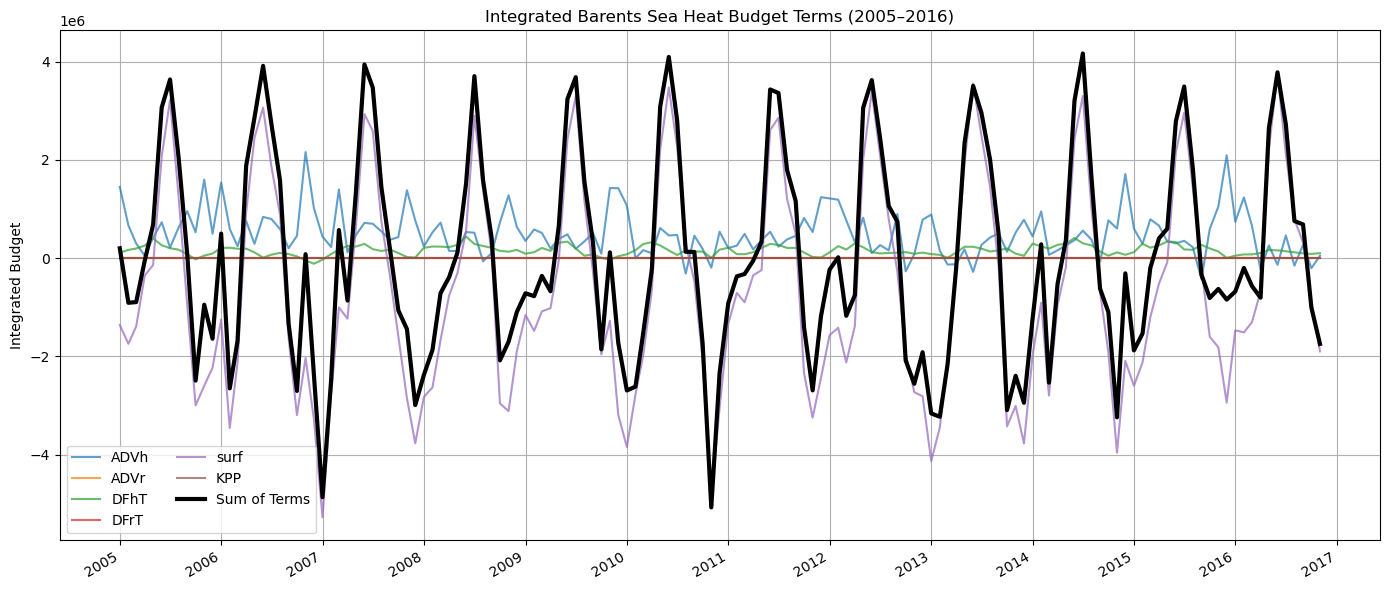

In [59]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14, 6))

dates = datetimes[:-1]

sum_terms = np.zeros(len(dates))

for term, values in budget_ts.items():
    if term.upper() != "TEND":
        values = np.array(values)
        ax.plot(dates, values, label=term, alpha=0.7)
        sum_terms += values

# Plot sum of all non-TEND terms
ax.plot(
    dates,
    sum_terms,
    'k',
    linewidth=3,
    label='Tend'
)

ax.set_title("Integrated Barents Sea Heat Budget Terms (2005–2016)")
ax.set_ylabel("Integrated Budget")
ax.grid()

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.autofmt_xdate()
ax.legend(ncol=2)

plt.tight_layout()
plt.show()

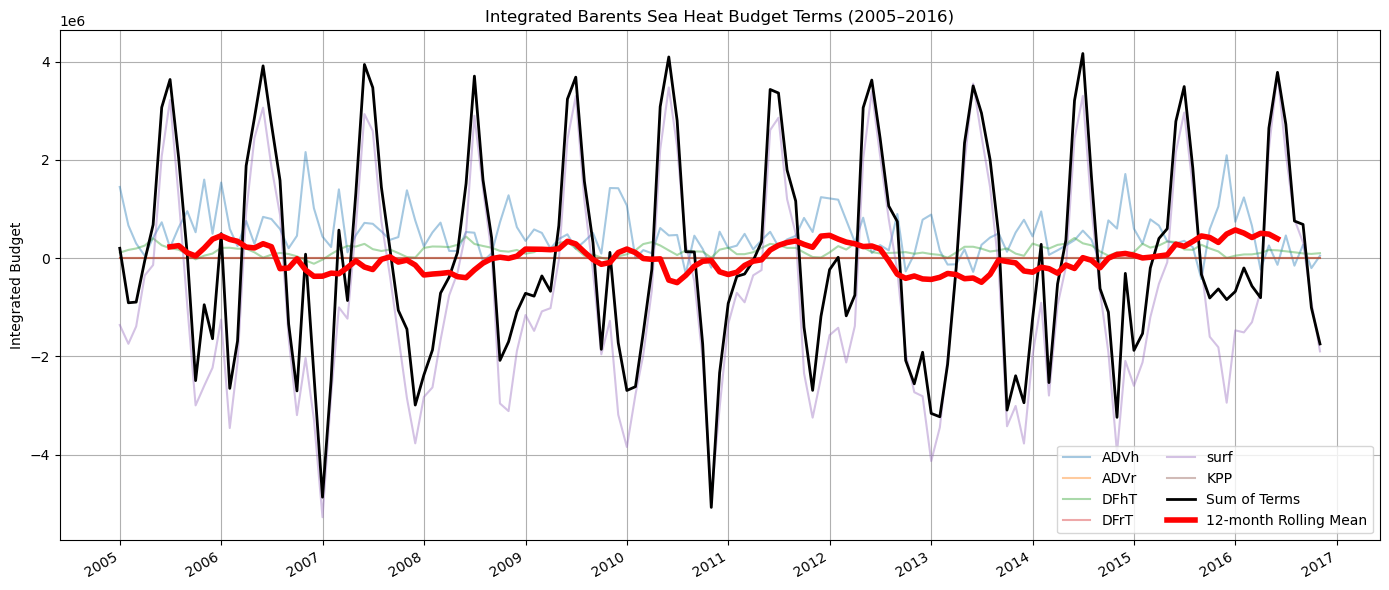

In [60]:
import matplotlib.dates as mdates
import pandas as pd

fig, ax = plt.subplots(figsize=(14, 6))

dates = datetimes[:-1]

sum_terms = np.zeros(len(dates))

for term, values in budget_ts.items():
    if term.upper() != "TEND":
        values = np.array(values)
        ax.plot(dates, values, label=term, alpha=0.4)
        sum_terms += values

# Sum of all non-TEND terms
ax.plot(
    dates,
    sum_terms,
    'k',
    linewidth=2,
    label='Sum of Terms'
)

# 12-month rolling mean
rolling_mean = (
    pd.Series(sum_terms, index=dates)
      .rolling(window=12, center=True)
      .mean()
)

ax.plot(
    rolling_mean.index,
    rolling_mean.values,
    'r',
    linewidth=4,
    label='12-month Rolling Mean'
)

ax.set_title("Integrated Barents Sea Heat Budget Terms (2005–2016)")
ax.set_ylabel("Integrated Budget")
ax.grid()

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.autofmt_xdate()
ax.legend(ncol=2)

plt.tight_layout()
plt.show()

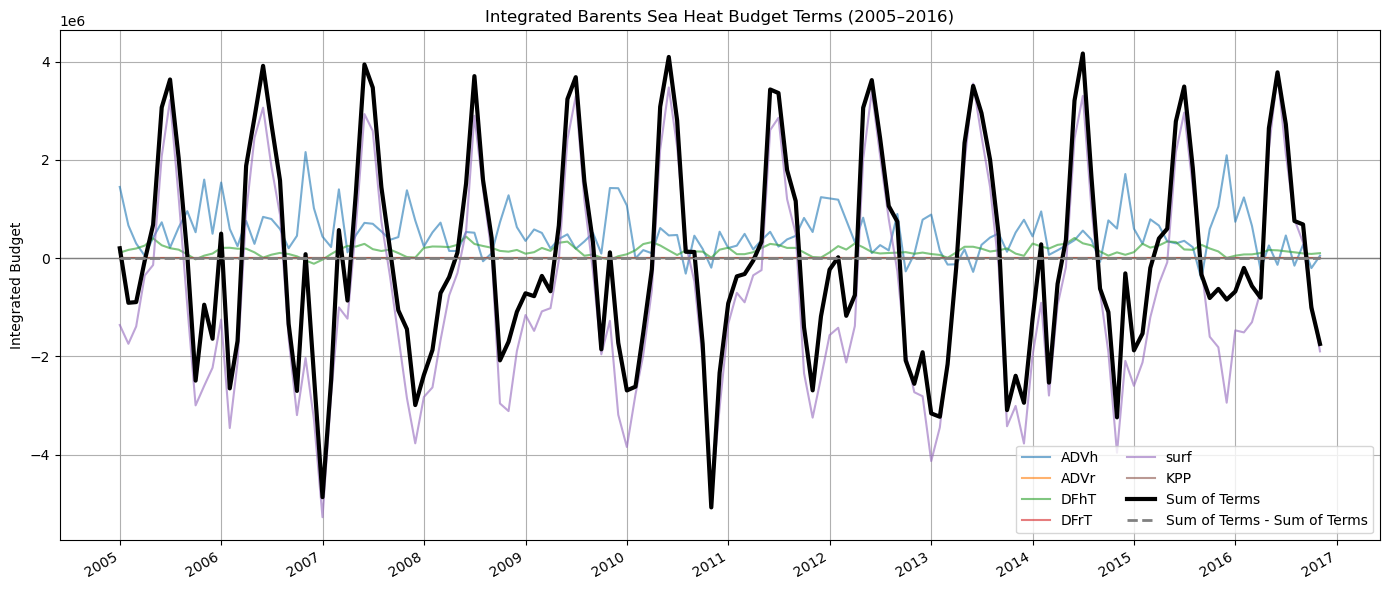

In [62]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14, 6))

dates = datetimes[:-1]

sum_terms = np.zeros(len(dates))

for term, values in budget_ts.items():
    if term.upper() != "TEND":
        values = np.array(values)
        ax.plot(dates, values, label=term, alpha=0.6)
        sum_terms += values

# Sum of all non-TEND terms
ax.plot(
    dates,
    sum_terms,
    'k',
    linewidth=3,
    label='Sum of Terms'
)

# Closure check: (sum of terms) - (sum of terms) = 0
closure_check = sum_terms - sum_terms

ax.plot(
    dates,
    closure_check,
    '--',
    color='gray',
    linewidth=2,
    label='Sum of Terms - Sum of Terms'
)

ax.axhline(0, color='gray', linewidth=1)

ax.set_title("Integrated Barents Sea Heat Budget Terms (2005–2016)")
ax.set_ylabel("Integrated Budget")
ax.grid()

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.autofmt_xdate()
ax.legend(ncol=2)

plt.tight_layout()
plt.show()

In [68]:
label_map = {
    "ADVh": "H-Adv",
    "ADVr": "V-Adv",
    "DFh":  "H-Mix",
    "DFr":  "V-Mix",
    "KPP":  "Conv",
    "surf": "Surface",
}

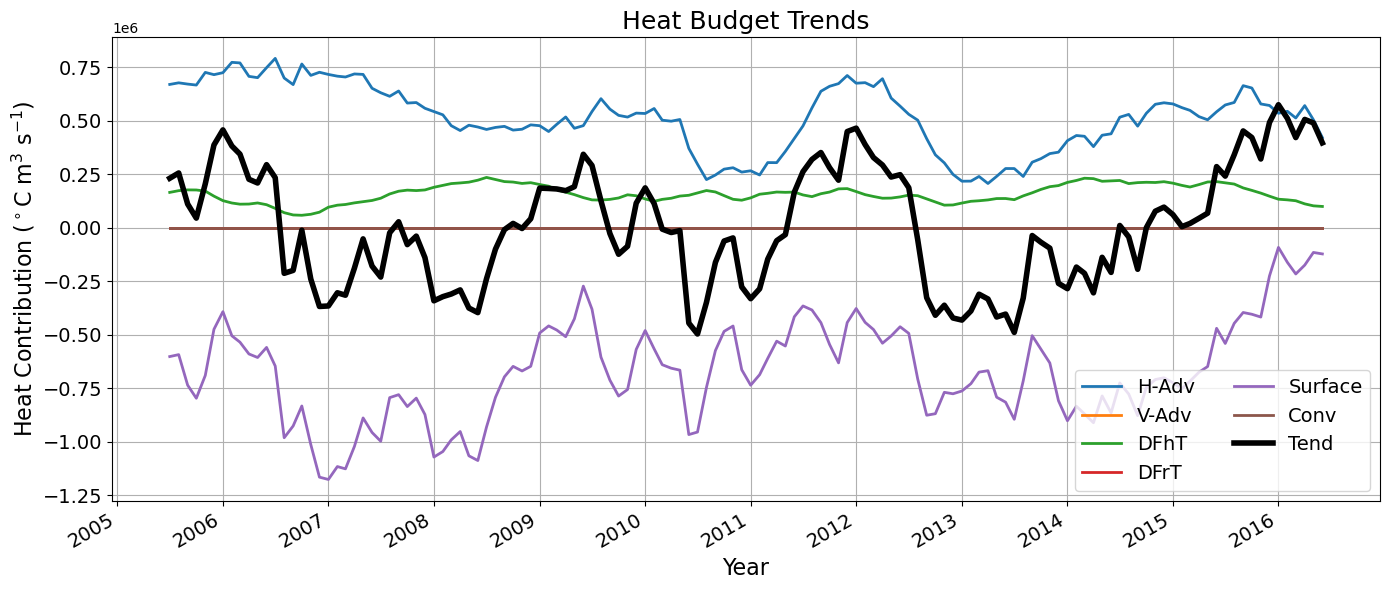

In [73]:
import matplotlib.dates as mdates
import pandas as pd

fig, ax = plt.subplots(figsize=(14, 6))

dates = datetimes[:-1]

sum_terms = np.zeros(len(dates))

for term, values in budget_ts.items():

    if term.upper() == "TEND":
        continue

    values = np.array(values)

    rolling = (
        pd.Series(values, index=dates)
        .rolling(window=12, center=True)
        .mean()
    )

    ax.plot(
        rolling.index,
        rolling.values,
        linewidth=2,
        label=label_map.get(term, term)
    )

    sum_terms += values

# 12-month running mean of total tendency
rolling_sum = (
    pd.Series(sum_terms, index=dates)
    .rolling(window=12, center=True)
    .mean()
)

ax.plot(
    rolling_sum.index,
    rolling_sum.values,
    'k',
    linewidth=4,
    label='Tend'
)

ax.set_title("Heat Budget Trends", fontsize=18)

ax.set_xlabel("Year", fontsize=16)
ax.set_ylabel(
    r"Heat Contribution ($^\circ$C m$^3$ s$^{-1}$)",
    fontsize=16
)

ax.grid()

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.tick_params(axis='both', labelsize=14)

fig.autofmt_xdate()

ax.legend(ncol=2, fontsize=14, loc="lower right")

plt.tight_layout()
plt.savefig("example_heatbudget.png",dpi=300)
plt.show()